In [67]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

load_dotenv()

client_id = os.getenv("CLIENT_ID")
client_secret = os.getenv("CLIENT_SECRET")
redirect_uri = os.getenv("REDIRECT_URI")

print(client_id,client_secret)

scope = "playlist-modify-public user-library-read user-read-playback-state user-modify-playback-state user-library-read"
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id=client_id,
    client_secret=client_secret,
    redirect_uri=redirect_uri,
    scope=scope,
    requests_timeout=10
))

908ea1825b034196a9abe8bc0ba9209d d12c0c16cf554009a2e0fb1a88f1f322


In [68]:
df = pd.read_csv("dataset.csv", index_col = 0)

In [69]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [70]:
df['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [71]:
acoustic_music = df[df['track_genre'] == 'acoustic']
acoustic_music.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


**Cleaning the dataset - Data preprocessing**

In [73]:
df_clean = df.drop_duplicates()

In [74]:
df_clean = df_clean.drop_duplicates(subset=['track_name', 'artists'])

In [75]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,81344.0,34.635966,19.438777,0.000,21.00000,35.000000,49.00000,100.000
duration_ms,81344.0,231411.652230,116494.470513,0.000,173871.00000,215204.000000,267346.00000,5237295.000
danceability,81344.0,0.559275,0.177746,0.000,0.44600,0.573000,0.69000,0.985
energy,81344.0,0.635025,0.258639,0.000,0.45500,0.678000,0.85700,1.000
key,81344.0,5.285922,3.557612,0.000,2.00000,5.000000,8.00000,11.000
loudness,81344.0,-8.593940,5.304765,-49.531,-10.45125,-7.262000,-5.14000,4.532
mode,81344.0,0.632339,0.482171,0.000,0.00000,1.000000,1.00000,1.000
speechiness,81344.0,0.088992,0.116628,0.000,0.03610,0.049100,0.08700,0.965
acousticness,81344.0,0.329670,0.339961,0.000,0.01590,0.190000,0.62900,0.996
instrumentalness,81344.0,0.184731,0.331591,0.000,0.00000,0.000089,0.15300,1.000


**Data Visualisation**

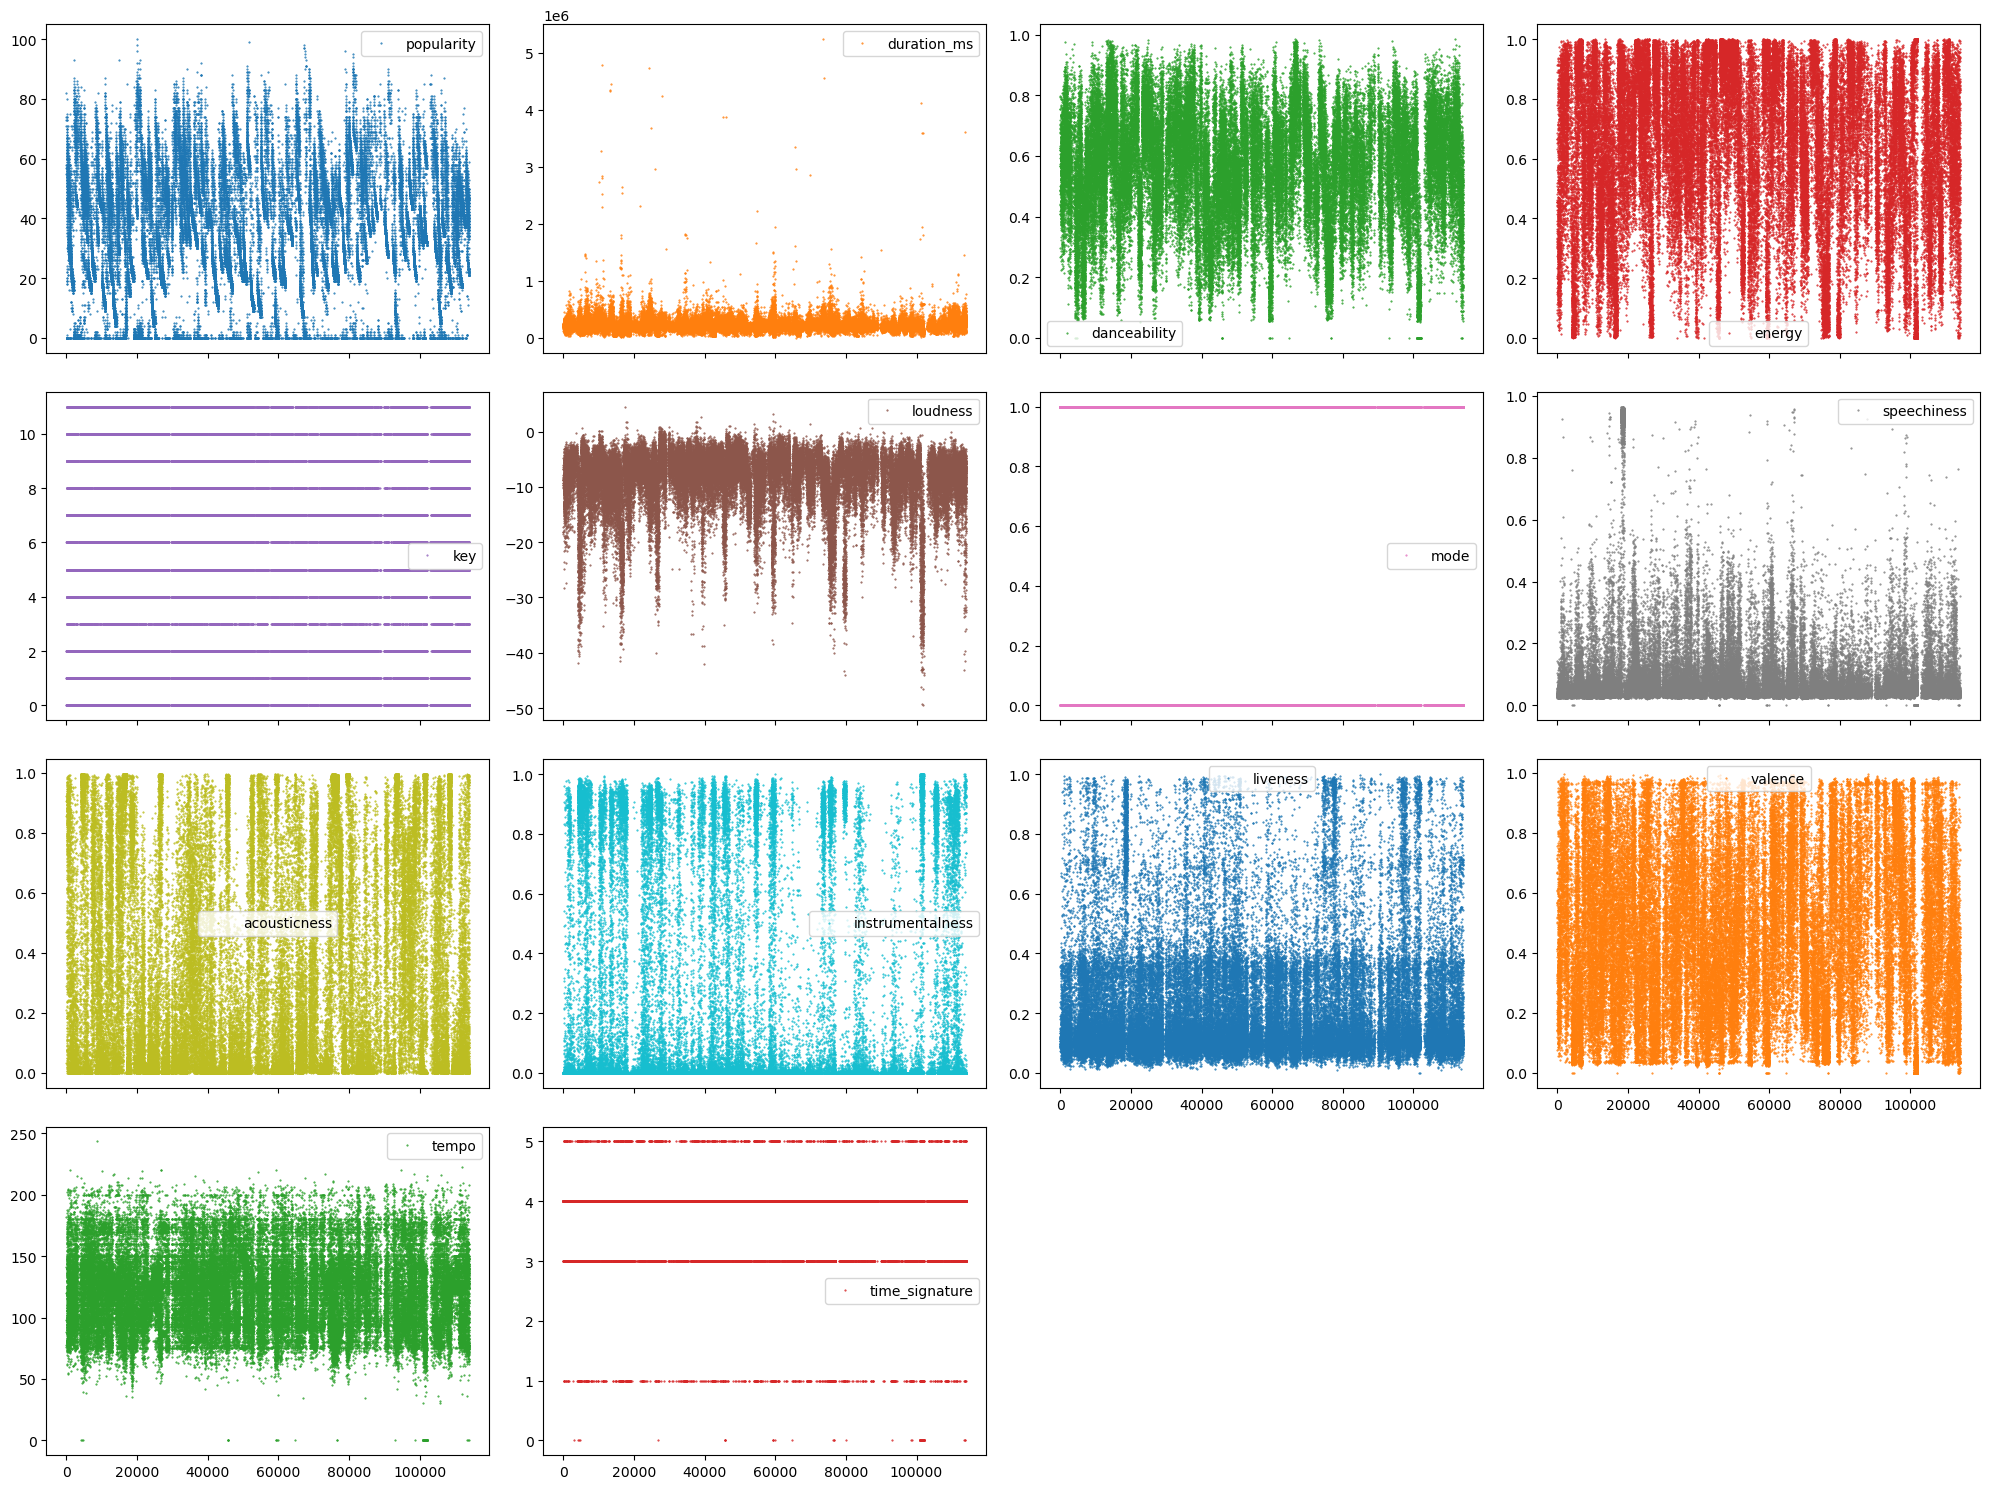

In [77]:
df_clean.plot(lw=0, marker = ".", subplots = True, layout = (-1,4), figsize = (20,15), markersize = 1);
plt.tight_layout()

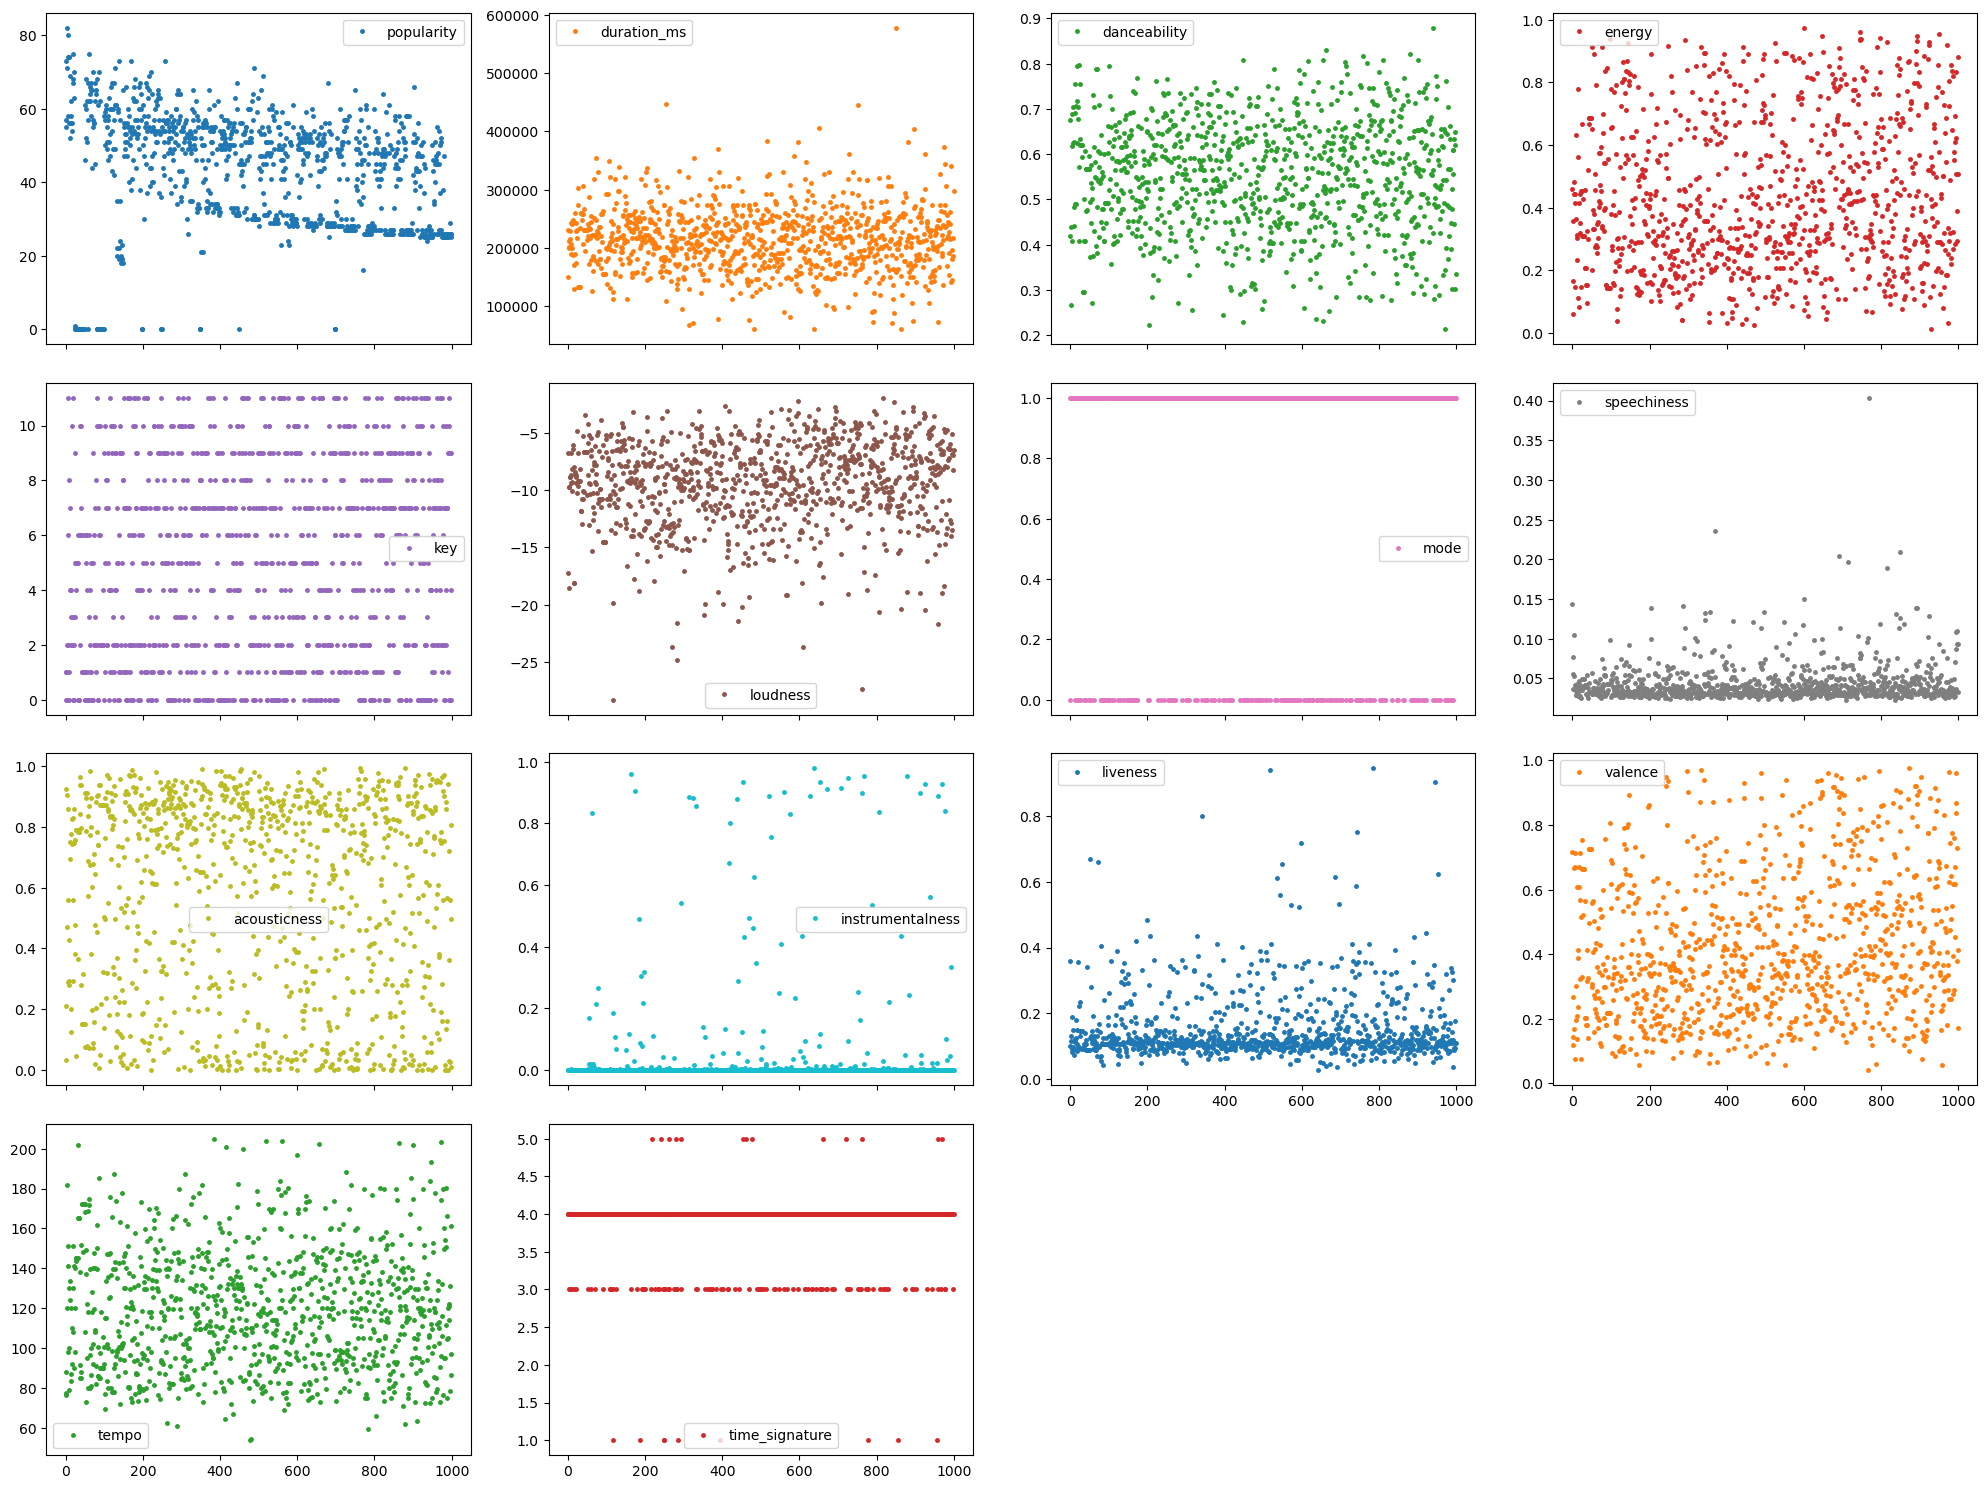

In [78]:
acoustic_music.plot(lw=0, marker = ".", subplots = True, layout = (-1,4), figsize = (20,15), markersize = 5);
plt.tight_layout()

In [79]:
techno_music = df[df['track_genre'] == 'techno']

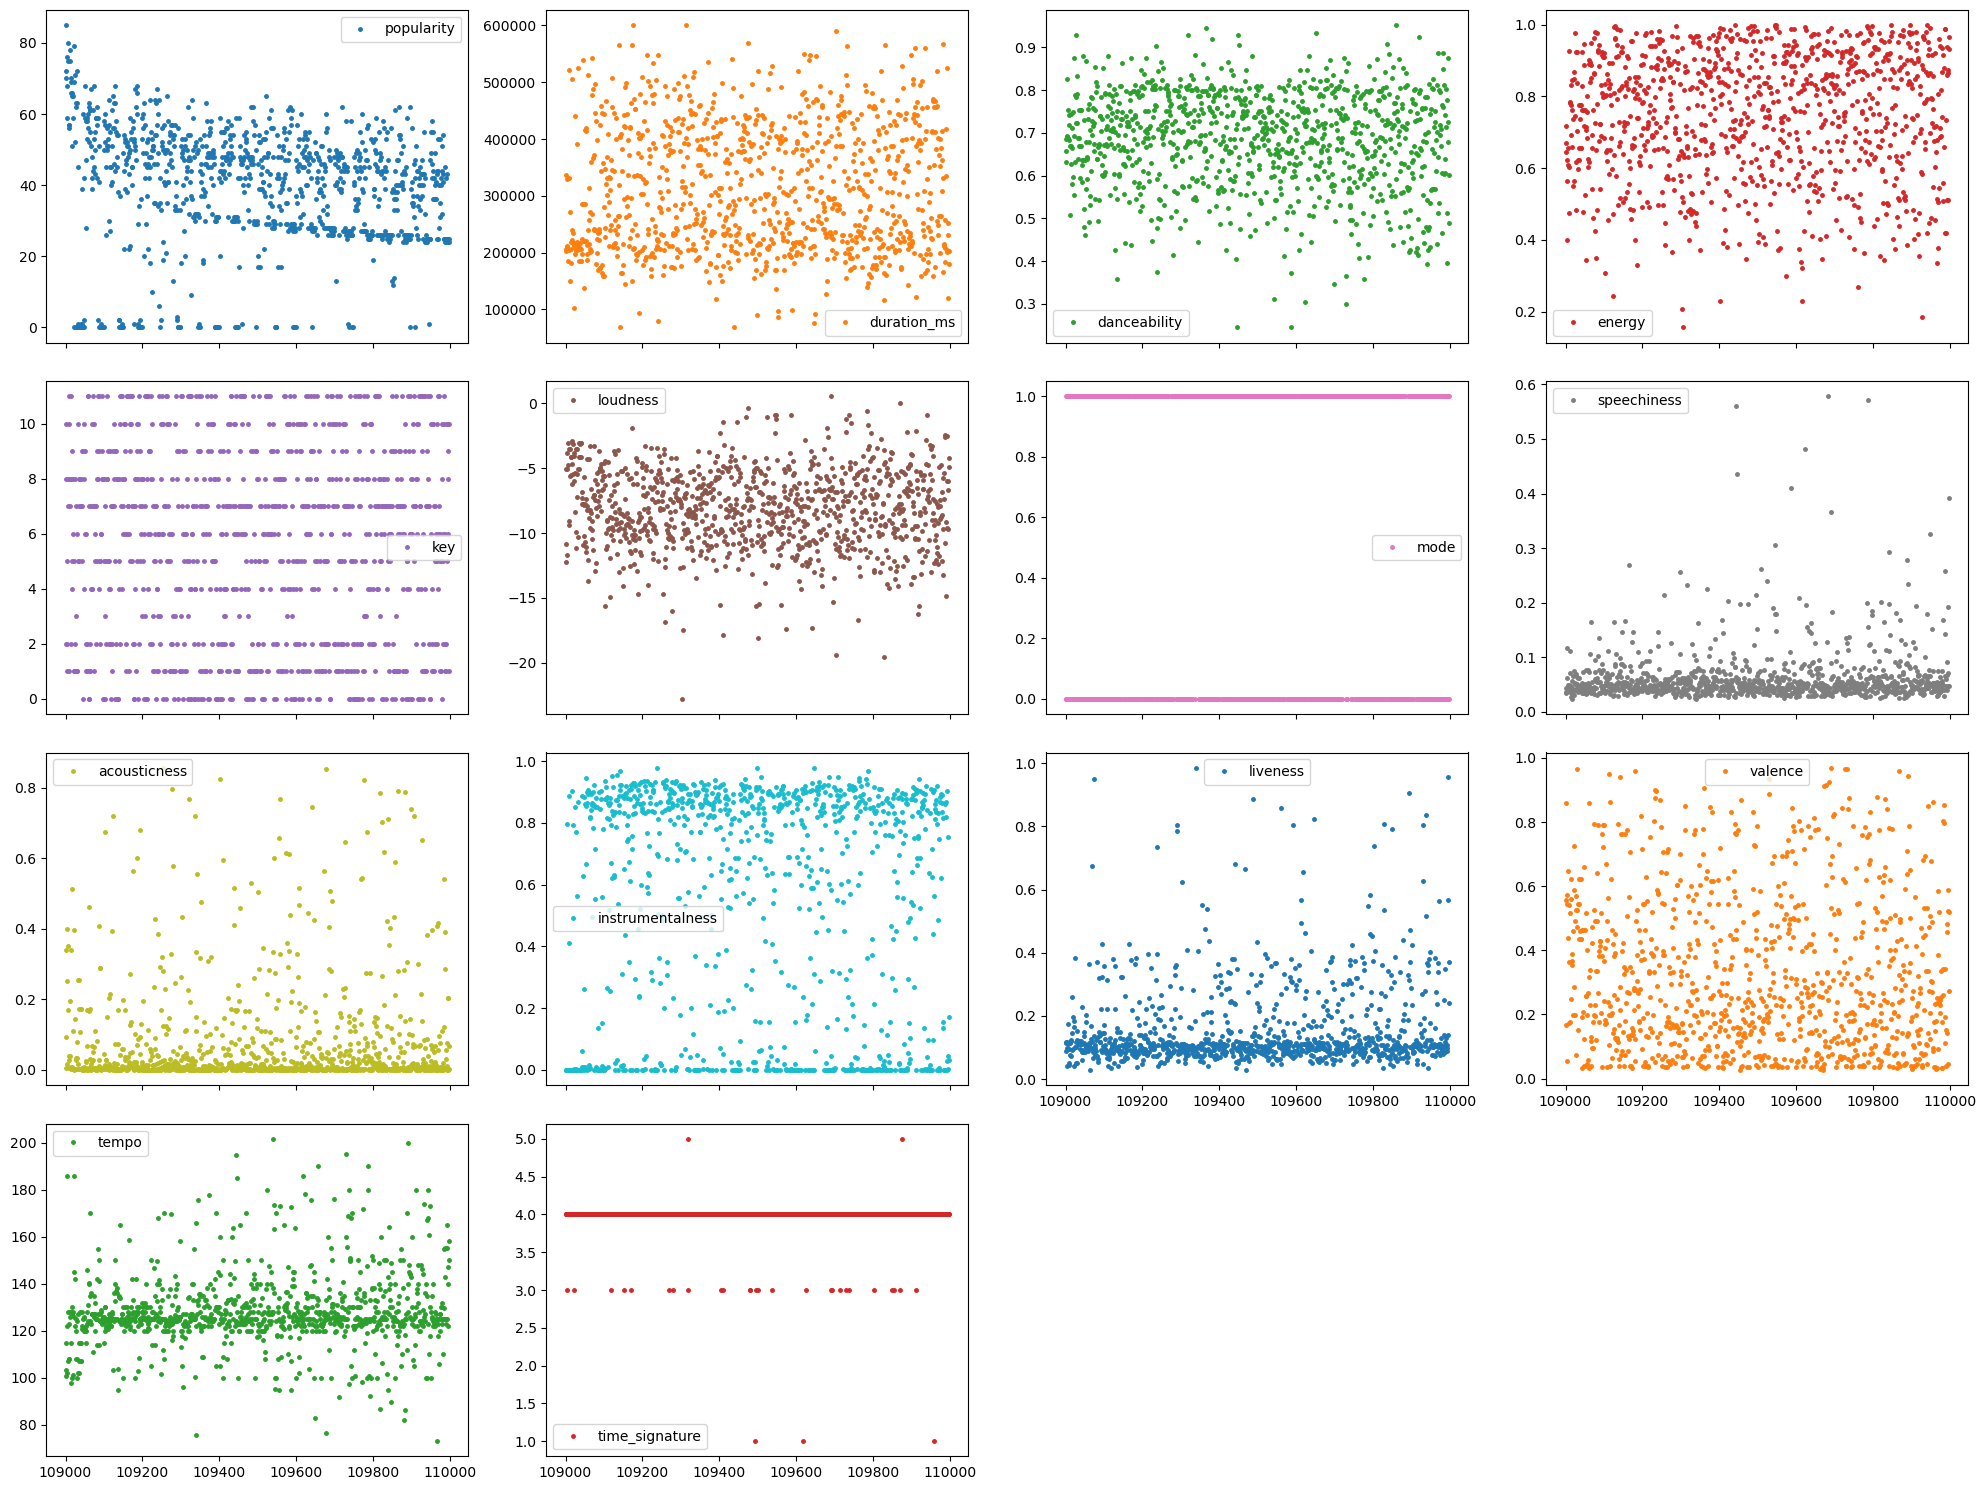

In [80]:
techno_music.plot(lw=0, marker = ".", subplots = True, layout = (-1,4), figsize = (20,15), markersize = 5);
plt.tight_layout()

In [81]:
df_clean.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [82]:
df_clean.dropna()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [83]:
df_clean.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [84]:
df_clean = df_clean.reset_index(drop=True)

In [85]:
df_clean.duplicated().sum()

0

In [86]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81344 entries, 0 to 81343
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          81344 non-null  object 
 1   artists           81343 non-null  object 
 2   album_name        81343 non-null  object 
 3   track_name        81343 non-null  object 
 4   popularity        81344 non-null  int64  
 5   duration_ms       81344 non-null  int64  
 6   explicit          81344 non-null  bool   
 7   danceability      81344 non-null  float64
 8   energy            81344 non-null  float64
 9   key               81344 non-null  int64  
 10  loudness          81344 non-null  float64
 11  mode              81344 non-null  int64  
 12  speechiness       81344 non-null  float64
 13  acousticness      81344 non-null  float64
 14  instrumentalness  81344 non-null  float64
 15  liveness          81344 non-null  float64
 16  valence           81344 non-null  float6

In [87]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


**Checking ranges of all audio features**

In [89]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 
                   'acousticness', 'instrumentalness', 'liveness', 
                   'valence', 'tempo']

for col in audio_features:
    print(f"{col}: min={df[col].min():.3f}, max={df[col].max():.3f}")

danceability: min=0.000, max=0.985
energy: min=0.000, max=1.000
loudness: min=-49.531, max=4.532
speechiness: min=0.000, max=0.965
acousticness: min=0.000, max=0.996
instrumentalness: min=0.000, max=1.000
liveness: min=0.000, max=1.000
valence: min=0.000, max=0.995
tempo: min=0.000, max=243.372


In [182]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
raw_features = df_clean[audio_features].copy()   # before scaling
df_clean[audio_features] = sc.fit_transform(df_clean[audio_features])
df_clean[[f'{c}_raw' for c in audio_features]] = raw_features

In [184]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [186]:
df_clean.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,track_genre,danceability_raw,energy_raw,loudness_raw,speechiness_raw,acousticness_raw,instrumentalness_raw,liveness_raw,valence_raw,tempo_raw
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.656701,-0.672851,1,...,acoustic,0.656701,-0.672851,0.348357,0.463078,-0.875018,-0.557105,0.697427,0.955723,-1.136061
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,-0.783568,-1.813442,1,...,acoustic,-0.783568,-1.813442,-1.628934,-0.108828,1.748240,-0.557091,-0.598786,-0.745232,-1.482176
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,-0.682299,-1.067225,0,...,acoustic,-0.682299,-1.067225,-0.214914,-0.285459,-0.352014,-0.557108,-0.518088,-1.303357,-1.520578
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,-1.649981,-2.224829,0,...,acoustic,-1.649981,-2.224829,-1.870228,-0.451801,1.692351,-0.556895,-0.442433,-1.216032,1.978013
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.330390,-0.742446,2,...,acoustic,0.330390,-0.742446,-0.204923,-0.312039,0.409843,-0.557108,-0.690075,-1.124909,-0.072888


In [188]:
df_clean.tail()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,track_genre,danceability_raw,energy_raw,loudness_raw,speechiness_raw,acousticness_raw,instrumentalness_raw,liveness_raw,valence_raw,tempo_raw
81339,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,-2.178830,-1.546660,5,...,world-music,-2.178830,-1.546660,-1.470208,-0.401212,0.912845,2.241537,-0.672927,-1.630260,0.127784
81340,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,-2.167578,-2.002897,0,...,world-music,-2.167578,-2.002897,-1.833092,-0.419218,1.954147,2.386295,-0.578611,-1.626083,-1.224946
81341,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.392277,-1.183217,0,...,world-music,0.392277,-1.183217,-0.433775,-0.402927,1.580573,-0.557108,-0.685032,1.062032,0.339642
81342,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.155983,-0.498862,7,...,world-music,0.155983,-0.498862,-0.432644,-0.508391,0.150988,-0.557108,0.253587,-0.190903,0.458532
81343,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,-0.187207,-0.572324,1,...,world-music,-0.187207,-0.572324,-0.303514,-0.141411,1.033448,-0.557108,-0.657796,0.929145,-1.425453


***PREDICTING SIMILAR SONGS BASED ON USER INPUT OF ALL FEATURES USING COSINE SIMILARITY***

In [191]:
from sklearn.metrics.pairwise import cosine_similarity

feature_matrix = df_clean[audio_features].values

In [193]:
def get_recommendations_cosine(user_input_dict, df, sc, feature_matrix, audio_features, top_n=10):
    
    user_vector = np.array([[user_input_dict[feat] for feat in audio_features]])
    
    user_vector_scaled = sc.transform(user_vector)
    
    similarities = cosine_similarity(user_vector_scaled, feature_matrix)[0]
    top_indices = similarities.argsort()[::-1][:top_n]
    
    results = df.iloc[top_indices].copy()
    results['similarity_score'] = similarities[top_indices]
    return results

In [195]:
user_query = {
    'danceability': 0.8, 'energy': 0.9, 'loudness': -5.0,
    'speechiness': 0.05, 'acousticness': 0.1, 'instrumentalness': 0.0,
    'liveness': 0.15, 'valence': 0.7, 'tempo': 128
}
recs = get_recommendations_cosine(user_query, df_clean, sc, feature_matrix, audio_features)
print(recs[['track_name', 'artists', 'similarity_score']])

                     track_name                        artists  \
19552  In Control (feat. Selin)  Mahmut Orhan;Ali Arutan;Selin   
49667               Veera Soora             Yuvan Shankar Raja   
47464           Dangerous - Raw        Jahvillani;Jada Kingdom   
20027                 All Of Me         Teddy Beats;Britt Lari   
64698             Vem Me Beijar                         Maneva   
5814             Drinkin’ Alone               The Steeldrivers   
30923             All Your Love                          Jakob   
27392            Mixed Emotions                         Josh A   
17832                     Godly                       Omah Lay   
69037         Preciso Desse Mel              RDN;Suel;Ferrugem   

       similarity_score  
19552          0.948146  
49667          0.946486  
47464          0.944082  
20027          0.938534  
64698          0.926743  
5814           0.926165  
30923          0.922328  
27392          0.915074  
17832          0.909914  
69037        

C:\Users\kush3\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [197]:
from tabulate import tabulate

headers = ["Track Name", "Artists", "Genre", "Similarity Score"]

print(tabulate(recs[['track_name', 'artists', 'track_genre','similarity_score']], headers=headers, tablefmt="grid"))

+-------+--------------------------+-------------------------------+------------+--------------------+
|       | Track Name               | Artists                       | Genre      |   Similarity Score |
+=======+==========================+===============================+============+====================+
| 19552 | In Control (feat. Selin) | Mahmut Orhan;Ali Arutan;Selin | deep-house |           0.948146 |
+-------+--------------------------+-------------------------------+------------+--------------------+
| 49667 | Veera Soora              | Yuvan Shankar Raja            | k-pop      |           0.946486 |
+-------+--------------------------+-------------------------------+------------+--------------------+
| 47464 | Dangerous - Raw          | Jahvillani;Jada Kingdom       | j-dance    |           0.944082 |
+-------+--------------------------+-------------------------------+------------+--------------------+
| 20027 | All Of Me                | Teddy Beats;Britt Lari        | deep

In [199]:
def get_song_features(song_name):
    return (df_clean[df_clean['track_name'] == song_name])

In [201]:
get_song_features("Waka Waka")

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,track_genre,danceability_raw,energy_raw,loudness_raw,speechiness_raw,acousticness_raw,instrumentalness_raw,liveness_raw,valence_raw,tempo_raw
50874,5hSNkAoKDa3vBZLhhb0SmR,Electric Slide DJ's,ELECTRIC SLIDE DANCE PARTY,Waka Waka,14,202677,False,0.977386,0.83505,6,...,kids,0.977386,0.83505,0.700684,1.672056,-0.219645,-0.557108,-0.665866,1.627751,0.159249


In [203]:
from sklearn.neighbors import NearestNeighbors

feature_matrix = df_clean[audio_features].values

knn = NearestNeighbors(n_neighbors=10, metric = 'euclidean')
knn.fit(feature_matrix)


NearestNeighbors(metric='euclidean', n_neighbors=10)

In [204]:
def get_recommendations_knn(user_input_dict, df, sc, knn_model, audio_features, top_n = 10):

    user_vector = np.array([[user_input_dict[feat] for feat in audio_features]])
    user_vector_scaled = sc.transform(user_vector)

    distance, indices = knn_model.kneighbors(user_vector_scaled, n_neighbors = top_n)
    

    results = df.iloc[indices[0]].copy()
    results['distance'] = distance[0]
    return results.sort_values('distance')

In [205]:
headers = ['Track Name', 'Artist Name', 'Genre','Similarity Score']
recs = get_recommendations_knn(user_query, df_clean, sc, knn, audio_features)
print(tabulate(recs[['track_name', 'artists', 'track_genre','distance']], headers = headers, tablefmt = 'grid'))


+-------+-----------------------------------+--------------------------+-----------+--------------------+
|       | Track Name                        | Artist Name              | Genre     |   Similarity Score |
+=======+===================================+==========================+===========+====================+
|  7133 | Call The Doctor                   | J.J. Cale                | blues     |            124.064 |
+-------+-----------------------------------+--------------------------+-----------+--------------------+
| 79530 | Undenied                          | Portishead               | trip-hop  |            124.839 |
+-------+-----------------------------------+--------------------------+-----------+--------------------+
|  1027 | Makoti                            | Hugh Masekela            | afrobeat  |            124.845 |
+-------+-----------------------------------+--------------------------+-----------+--------------------+
| 22602 | Hip Hip Pooh Rah                  | 

C:\Users\kush3\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [215]:
song_choice = input("Enter your song choice :")

matches = df_clean[df_clean['track_name'].str.contains(song_choice, case=False, na=False)]
if len(matches) > 1:
    print(matches[['track_name', 'artists']])
    idx = int(input("Enter the row index of the correct song: "))
    song_choice = matches.loc[idx, 'track_name']
else:
    song_choice = song_choice
    


    
df_new = get_song_features(song_choice)
user_song = df_new.to_dict(orient = 'index')
print("Similar songs to",song_choice, "Sung by:", df_clean[df_clean['track_name'] == song_choice]['artists'])
for sno, song_feat in user_song.items():
    recs = get_recommendations_knn(song_feat, df_clean, sc, knn, audio_features)
    print(tabulate(recs[['track_name', 'artists', 'track_genre','distance']], headers = headers, tablefmt = 'grid'))
    

Enter your song choice : die trying


       track_name         artists
33295  Die Trying  New Model Army
39244  Die Trying    Digital Punk


Enter the row index of the correct song:  33295


Similar songs to Die Trying Sung by: 33295    New Model Army
39244      Digital Punk
Name: artists, dtype: object
+-------+---------------------+---------------------------------------------+-------------------+--------------------+
|       | Track Name          | Artist Name                                 | Genre             |   Similarity Score |
+=======+=====================+=============================================+===================+====================+
| 33295 | Die Trying          | New Model Army                              | goth              |        7.49401e-16 |
+-------+---------------------+---------------------------------------------+-------------------+--------------------+
| 71512 | Oh Love             | Delaney Bailey                              | singer-songwriter |        0.464899    |
+-------+---------------------+---------------------------------------------+-------------------+--------------------+
| 44454 | Chitthi Bhitra      | Sajjan Raj Vaidya    

C:\Users\kush3\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\kush3\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
